In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

CSV_PATH = Path("/media/DATA/FER_processed/data/final")
CROPPED_DATA_PATH = Path("/media/DATA/FER_data/cropped")

import sys
sys.path.append('../external/emonet')
sys.path.append('../external/fairface')
sys.path.append('../external')

# Now you can import emonet modules
from emonet.models import EmoNet
from fairfacewrapper import predict_fairface

In [49]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
data_faces = pd.read_csv(CSV_PATH / "faces.csv")
display(data_faces)
print(data_faces.columns)

data_faces['original_agegroup'] = data_faces['original_age_group']

for column in ['label', 'age', 'gender', 'race', 'race4', 
               'original_gender', 'original_age']:
    print(column, data_faces[column].unique())

,dataset_name,id,img_path,partition,label,subject,sequence,cropped_img,original_gender,age,...,gender_scores_fair,race,race_conf_fair,race_scores_fair,race4,race_conf_fair_4,race_scores_fair_4,age2,original_age_group,original_age
0,faces,angry_0150928a43835565f34e960bde3601f2,125_y_f_a_a.jpg,train,angry,125,angry_0150928a43835565f34e960bde3601f2,faces/angry_0150928a43835565f34e960bde3601f2.png,female,20-29,...,[0.20390971 0.79609036],White,0.999907,[9.9990737e-01 6.1324186e-09 4.2407803e-05 5.0...,White,0.999846,[9.9984574e-01 5.7200850e-08 1.3712540e-04 1.6...,19.780220,young,21
1,faces,angry_022734fdb791ef7c70b46d0d45bba320,104_m_m_a_b.jpg,train,angry,104,angry_022734fdb791ef7c70b46d0d45bba320,faces/angry_022734fdb791ef7c70b46d0d45bba320.png,male,40-49,...,[9.9969429e-01 3.0570306e-04],White,0.730454,[7.3045397e-01 9.1001962e-04 2.5616553e-01 2.3...,White,0.980163,[0.9801625 0.00113623 0.01197158 0.0067297 ],41.135345,middle-age,45
2,faces,angry_053a0af5e55f80ac7b15a46a50c5a900,164_o_f_a_b.jpg,train,angry,164,angry_053a0af5e55f80ac7b15a46a50c5a900,faces/angry_053a0af5e55f80ac7b15a46a50c5a900.png,female,60-69,...,[0.6128712 0.38712874],White,0.792837,[7.9283750e-01 1.0734903e-05 7.3576994e-02 2.5...,White,0.999761,[9.9976087e-01 3.5686222e-07 1.9291800e-04 4.5...,58.707116,old,79
3,faces,angry_0552ae975a5e294ba4b22778881dac24,030_o_f_a_a.jpg,train,angry,30,angry_0552ae975a5e294ba4b22778881dac24,faces/angry_0552ae975a5e294ba4b22778881dac24.png,female,50-59,...,[0.01957799 0.980422 ],White,0.952017,[9.5201671e-01 2.1224500e-05 1.7889854e-02 7.0...,White,0.991722,[9.9172217e-01 4.0251957e-06 7.4941893e-03 7.7...,45.033489,old,72
4,faces,angry_05a93199e384ac59d519d44550fbd4e7,163_y_f_a_a.jpg,train,angry,163,angry_05a93199e384ac59d519d44550fbd4e7,faces/angry_05a93199e384ac59d519d44550fbd4e7.png,female,20-29,...,[0.01495139 0.9850486 ],White,0.824087,[8.2408750e-01 2.3126058e-04 1.4618038e-01 2.2...,White,0.989659,[9.8965943e-01 8.7652239e-04 7.7949883e-03 1.6...,16.942121,young,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2047,faces,sad_fe1a3d8ea4581d364f25de56457455c1,073_m_f_s_a.jpg,train,sad,73,sad_fe1a3d8ea4581d364f25de56457455c1,faces/sad_fe1a3d8ea4581d364f25de56457455c1.png,female,50-59,...,[0.0033583 0.9966417],White,0.879230,[8.7923008e-01 3.8919119e-05 2.0862566e-02 5.9...,White,0.990393,[9.9039251e-01 2.2258533e-05 4.9925684e-03 4.5...,51.424328,middle-age,55
2048,faces,sad_fee5cd70799ba168293df64cf039fd67,097_m_f_s_b.jpg,train,sad,97,sad_fee5cd70799ba168293df64cf039fd67,faces/sad_fee5cd70799ba168293df64cf039fd67.png,female,50-59,...,[0.00260301 0.997397 ],White,0.645864,[6.4586347e-01 3.8732204e-04 2.8827614e-01 3.0...,White,0.916008,[9.1600794e-01 5.0452258e-04 7.4077666e-02 9.4...,49.573534,middle-age,54
2049,faces,sad_ff6f9f462e083f5f09007b79af466432,084_m_f_s_a.jpg,train,sad,84,sad_ff6f9f462e083f5f09007b79af466432,faces/sad_ff6f9f462e083f5f09007b79af466432.png,female,50-59,...,[0.14174281 0.8582572 ],White,0.985384,[9.8538381e-01 6.6118314e-06 3.7296955e-03 6.8...,White,0.998717,[9.987170e-01 3.341235e-05 9.875396e-04 2.6203...,54.935366,middle-age,54
2050,faces,sad_ff88ecb8fd7e289a325537057d56ed66,079_o_f_s_b.jpg,train,sad,79,sad_ff88ecb8fd7e289a325537057d56ed66,faces/sad_ff88ecb8fd7e289a325537057d56ed66.png,female,70+,...,[0.20413898 0.795861 ],White,0.954376,[9.5437551e-01 4.3737950e-06 7.8532854e-03 9.2...,White,0.995646,[9.9564642e-01 1.8668023e-06 4.2723971e-03 7.9...,70.542308,old,77


Index(['dataset_name', 'id', 'img_path', 'partition', 'label', 'subject',
       'sequence', 'cropped_img', 'original_gender', 'age', 'age_conf_fair',
       'age_scores_fair', 'gender', 'gender_conf_fair', 'gender_scores_fair',
       'race', 'race_conf_fair', 'race_scores_fair', 'race4',
       'race_conf_fair_4', 'race_scores_fair_4', 'age2', 'original_age_group',
       'original_age'],
      dtype='object')
label ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']
age ['20-29' '40-49' '60-69' '50-59' '30-39' '70+' '10-19']
gender ['Female' 'Male']
race ['White' 'Latino_Hispanic' 'Middle Eastern']
race4 ['White' 'Indian' 'Asian']
original_gender ['female' 'male']
original_age [21 45 79 72 24 46 48 73 20 71 22 30 54 51 74 75 50 27 78 26 70 49 77 25
 23 80 69 52 53 55 19 28 31 39 76 47 43]


## Initial assessment

/tmp/ipykernel_1823162/1429988450.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gender_acc = data_faces.groupby(['original_gender', 'label']).apply(


<Axes: xlabel='label', ylabel='original_gender'>

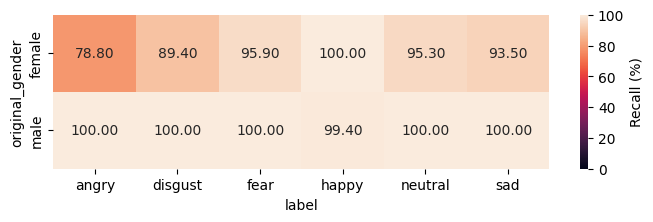

In [3]:
# 1. Gender accuracy by emotion
gender_acc = data_faces.groupby(['original_gender', 'label']).apply(
    lambda x: 100 * (x['gender'].map({'Female': 'female', 'Male': 'male'}) == x['original_gender']).mean()
).unstack().round(1)

# print("Gender Accuracy by Emotion:")
# print(gender_acc)
# print("\nLaTeX:")
# print(gender_acc.to_latex(caption="Gender classification accuracy (\\%) by original gender and emotion", 
#                          float_format="%.1f"))

plt.figure(figsize=(8,2))
sns.heatmap(gender_acc, annot=True, fmt='.2f', cmap=None, 
            cbar_kws={'label': 'Recall (%)'}, vmin=0, vmax=100,
            linewidths=0, linecolor='gray')

'young'

/tmp/ipykernel_1823162/2218022954.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gender_acc = data_mini.groupby(['original_gender', 'label']).apply(


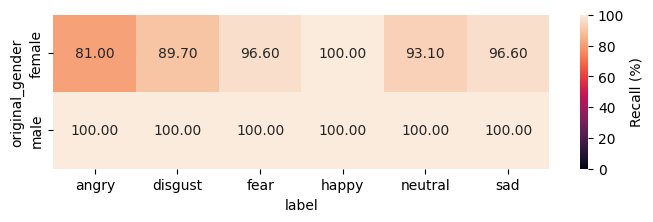

'middle-age'

/tmp/ipykernel_1823162/2218022954.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gender_acc = data_mini.groupby(['original_gender', 'label']).apply(


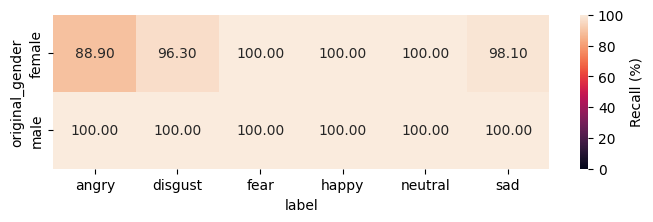

'old'

/tmp/ipykernel_1823162/2218022954.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gender_acc = data_mini.groupby(['original_gender', 'label']).apply(


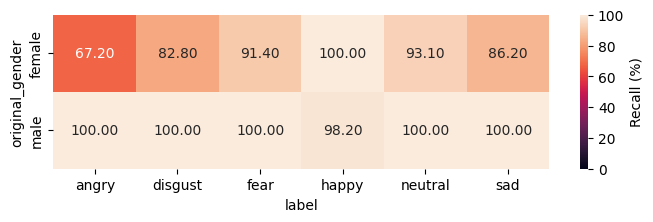

In [4]:
for age_group in ['young', 'middle-age', 'old']:
    data_mini = data_faces[data_faces['original_agegroup'] == age_group]
    display(age_group)
    
    gender_acc = data_mini.groupby(['original_gender', 'label']).apply(
        lambda x: 100 * (x['gender'].map({'Female': 'female', 'Male': 'male'}) == x['original_gender']).mean()
    ).unstack().round(1)
    
    plt.figure(figsize=(8,2))
    sns.heatmap(gender_acc, annot=True, fmt='.2f', cmap=None, 
                cbar_kws={'label': 'Recall (%)'}, vmin=0, vmax=100,
                linewidths=0, linecolor='gray')

    plt.show()

/tmp/ipykernel_1823162/951442538.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gender_acc = data_adfes.groupby(['original_gender', 'label']).apply(


<Axes: xlabel='label', ylabel='original_gender'>

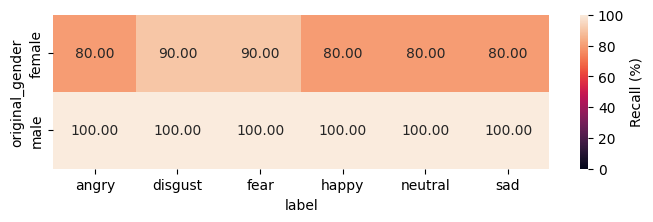

In [22]:
data_adfes = pd.read_csv(CSV_PATH / "adfes.csv")
# display(data_adfes)
# print(data_adfes.columns)

# 1. Gender accuracy by emotion
gender_acc = data_adfes.groupby(['original_gender', 'label']).apply(
    lambda x: 100 * (x['gender'].map({'Female': 'female', 'Male': 'male'}) == x['original_gender']).mean()
).unstack().round(1)

# print("Gender Accuracy by Emotion:")
# print(gender_acc)
# print("\nLaTeX:")
# print(gender_acc.to_latex(caption="Gender classification accuracy (\\%) by original gender and emotion", 
#                          float_format="%.1f"))

plt.figure(figsize=(8,2))
sns.heatmap(gender_acc, annot=True, fmt='.2f', cmap=None, 
            cbar_kws={'label': 'Recall (%)'}, vmin=0, vmax=100,
            linewidths=0, linecolor='gray')

In [40]:
import torch
import cv2
from skimage.transform import resize
from skimage import io

device = 'cuda:2'
n_classes = 8
model = EmoNet(n_expression=8).to(device)
state_dict = torch.load(f'../external/emonet/pretrained/emonet_8.pth', map_location=device)
model.load_state_dict(state_dict, strict=False)
model.eval()

transform_mean = [0.485, 0.456, 0.406]
transform_std = [0.229, 0.224, 0.225]
emotion_labels = ['neutral', 'happy', 'sad', 'surprise', 'fear', 'disgust', 'anger', 'contempt']

def predict_emotion(img_path):
    image_rgb = io.imread(img_path)[:,:,:3]
    image_rgb = cv2.resize(image_rgb, (256, 256))
    image_tensor = torch.Tensor(image_rgb).permute(2,0,1).to(device)/255.0
    
    with torch.no_grad():
        out = model(image_tensor.unsqueeze(0))
        logits = out['expression'].cpu().numpy()[0]
        pred_idx = np.argmax(logits)
    return emotion_labels[pred_idx], logits

for df in [data_adfes, data_faces]:
    emotions = []
    logits_list = []
    for img_path in df['cropped_img']:
        full_path = CROPPED_DATA_PATH / img_path
        emotion, logits = predict_emotion(str(full_path))
        emotions.append(emotion)
        logits_list.append(logits)
    df['emonet_emotion'] = emotions
    df['emonet_logits'] = logits_list

data_adfes.to_csv("../adfes_emonet.csv", index=False)
data_faces.to_csv("../faces_emonet.csv", index=False)

In [50]:
# Predict fairface demography

def predict_gender(img_path):
    image_rgb = io.imread(img_path)[:,:,:3]
    predicted = predict_fairface(image_rgb)
    
    return predicted['gender'].lower(), predicted['gender_scores']

for df in [data_adfes, data_faces]:
    genders = []
    logits_list = []
    for img_path in df['cropped_img']:
        full_path = CROPPED_DATA_PATH / img_path
        gender, logits = predict_gender(str(full_path))
        genders.append(gender)
        logits_list.append(logits)
    df['fairface_gender'] = genders
    df['fairface_logits'] = logits_list

data_adfes.to_csv("../adfes_emonet_fairface.csv", index=False)
data_faces.to_csv("../faces_emonet_fairface.csv", index=False)

/tmp/ipykernel_1823162/3899391090.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  emotion_acc = data_faces.groupby(['original_gender', 'label']).apply(


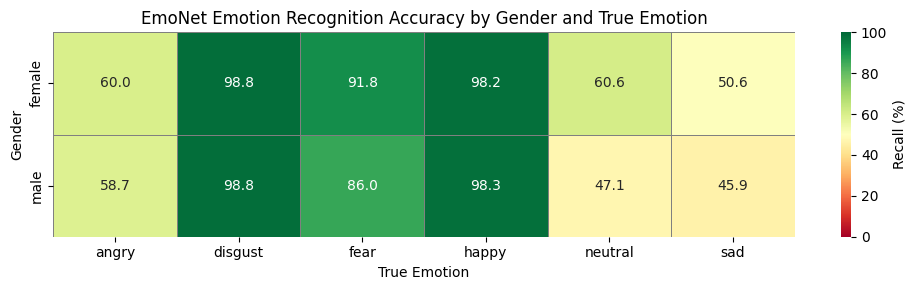

In [41]:
emotion_map = {
    'neutral': 'neutral',
    'happy': 'happy', 
    'sad': 'sad',
    'surprise': 'surprise',
    'fear': 'fear',
    'disgust': 'disgust',
    'anger': 'angry',
    'contempt': 'contempt'
}

data_faces['emonet_mapped'] = data_faces['emonet_emotion'].map(emotion_map)

emotion_acc = data_faces.groupby(['original_gender', 'label']).apply(
    lambda x: 100 * (x['emonet_mapped'] == x['label']).mean()
).unstack().round(1)

plt.figure(figsize=(10, 3))
sns.heatmap(emotion_acc, annot=True, fmt='.1f', cmap='RdYlGn', 
            cbar_kws={'label': 'Recall (%)'}, vmin=0, vmax=100,
            linewidths=0.5, linecolor='gray')
plt.title('EmoNet Emotion Recognition Accuracy by Gender and True Emotion')
plt.ylabel('Gender')
plt.xlabel('True Emotion')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1823162/1607328235.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  emotion_acc = data_mini.groupby(['original_gender', 'label']).apply(


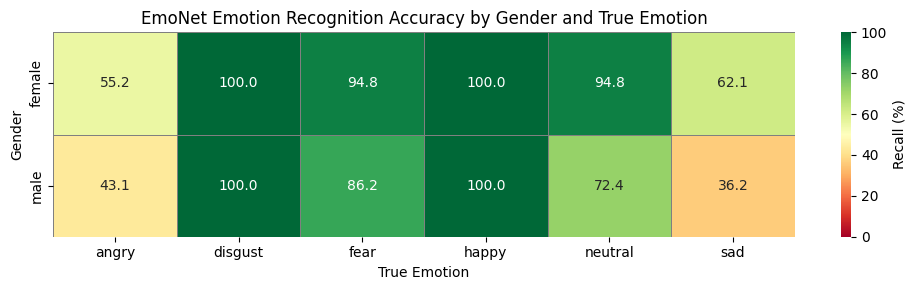

/tmp/ipykernel_1823162/1607328235.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  emotion_acc = data_mini.groupby(['original_gender', 'label']).apply(


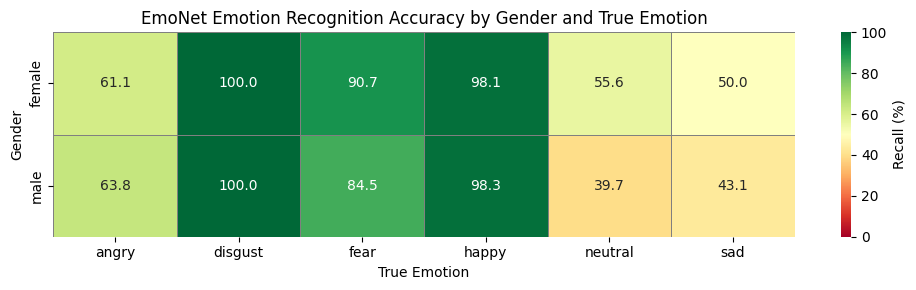

/tmp/ipykernel_1823162/1607328235.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  emotion_acc = data_mini.groupby(['original_gender', 'label']).apply(


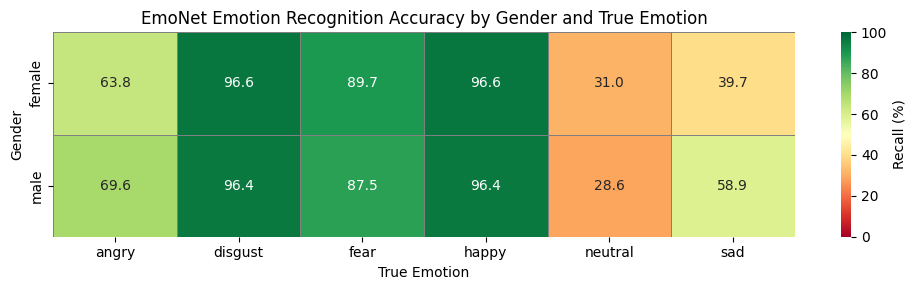

In [34]:
for age_group in ['young', 'middle-age', 'old']:
    data_mini = data_faces[data_faces['original_agegroup'] == age_group]

    emotion_acc = data_mini.groupby(['original_gender', 'label']).apply(
        lambda x: 100 * (x['emonet_mapped'] == x['label']).mean()
    ).unstack().round(1)
    
    plt.figure(figsize=(10, 3))
    sns.heatmap(emotion_acc, annot=True, fmt='.1f', cmap='RdYlGn', 
                cbar_kws={'label': 'Recall (%)'}, vmin=0, vmax=100,
                linewidths=0.5, linecolor='gray')
    plt.title('EmoNet Emotion Recognition Accuracy by Gender and True Emotion')
    plt.ylabel('Gender')
    plt.xlabel('True Emotion')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1823162/1565578412.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  emotion_acc = data_adfes.groupby(['original_gender', 'label']).apply(


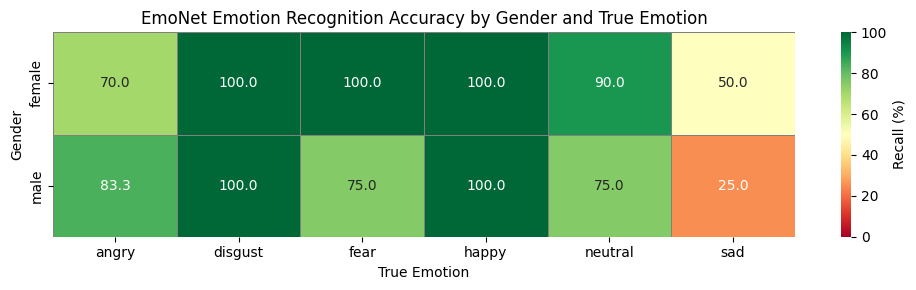

In [32]:
data_adfes['emonet_mapped'] = data_adfes['emonet_emotion'].map(emotion_map)

emotion_acc = data_adfes.groupby(['original_gender', 'label']).apply(
    lambda x: 100 * (x['emonet_mapped'] == x['label']).mean()
).unstack().round(1)

plt.figure(figsize=(10, 3))
sns.heatmap(emotion_acc, annot=True, fmt='.1f', cmap='RdYlGn', 
            cbar_kws={'label': 'Recall (%)'}, vmin=0, vmax=100,
            linewidths=0.5, linecolor='gray')
plt.title('EmoNet Emotion Recognition Accuracy by Gender and True Emotion')
plt.ylabel('Gender')
plt.xlabel('True Emotion')
plt.tight_layout()
plt.show()